# Vulnogram Version Analysis

This notebook analyzes Vulnogram version usage across CNAs to identify who is using outdated versions.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import re

## Load CVE Data

In [2]:
# Construct the base path relative to the current working directory
base_path = os.path.join(os.getcwd(), '..', '..', 'Data', 'CVE', 'cves')

data = []

# Traverse the directory tree
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith('.json'):
            file_path = os.path.join(root, file)
            with open(file_path, 'r') as f:
                cve_data = json.load(f)
                if isinstance(cve_data, dict):
                    cveId = cve_data.get('cveMetadata', {}).get('cveId')
                    shortName = cve_data.get('cveMetadata', {}).get('assignerShortName')
                    datePublished = cve_data.get('cveMetadata', {}).get('datePublished')
                    containers = cve_data.get('containers', {})
                    if isinstance(containers, dict):
                        cna = containers.get('cna', {})
                        if isinstance(cna, dict):
                            x_generator = cna.get('x_generator', {})
                            if isinstance(x_generator, dict):
                                x_generator = x_generator.get('engine')
                            else:
                                x_generator = None
                        else:
                            x_generator = None
                    else:
                        x_generator = None
                    data.append({
                        'cveId': cveId,
                        'shortName': shortName,
                        'x_generator': x_generator,
                        'datePublished': datePublished
                    })

cve_df = pd.DataFrame(data)
cve_df.rename(columns={
    'cveId': 'CVE',
    'shortName': 'CNA',
    'x_generator': 'Tool',
    'datePublished': 'Date'
}, inplace=True)

cve_df = cve_df.dropna(subset=['Date'])
print(f'Total CVE records loaded: {len(cve_df):,}')

Total CVE records loaded: 332,195


## Filter to Vulnogram Records

In [10]:
# Filter to only records that contain 'vulnogram' in the tool string
vulnogram_df = cve_df[cve_df['Tool'].str.contains('vulnogram', case=False, na=False)].copy()

# Extract the date part
vulnogram_df['Date'] = vulnogram_df['Date'].apply(
    lambda x: re.search(r'\d{4}-\d{2}-\d{2}', x).group(0) if pd.notna(x) and re.search(r'\d{4}-\d{2}-\d{2}', x) else None
)
vulnogram_df['Date'] = pd.to_datetime(vulnogram_df['Date'], errors='coerce')
vulnogram_df['Year'] = vulnogram_df['Date'].dt.year

# Extract the version number from the tool string
def extract_version(tool_str):
    match = re.search(r'(\d+\.\d+\.\d+[\w.-]*)', tool_str)
    return match.group(1) if match else 'unknown'

vulnogram_df['Version'] = vulnogram_df['Tool'].apply(extract_version)

print(f'Total Vulnogram CVE records: {len(vulnogram_df):,}')
print(f'Unique raw tool strings: {vulnogram_df["Tool"].nunique()}')
print(f'Unique versions: {vulnogram_df["Version"].nunique()}')

Total Vulnogram CVE records: 40,984
Unique raw tool strings: 19
Unique versions: 16


## Raw Vulnogram Tool Strings

In [11]:
# Show all unique raw tool strings and their counts
raw_versions = vulnogram_df['Tool'].value_counts().reset_index()
raw_versions.columns = ['Tool String', 'Count']
raw_versions['Percentage'] = (raw_versions['Count'] / raw_versions['Count'].sum() * 100).round(2)
raw_versions

,Tool String,Count,Percentage
0,Vulnogram 0.2.0,16826,41.06
1,Vulnogram 0.1.0-dev,15410,37.60
2,Vulnogram 0.0.9,5639,13.76
3,Vulnogram 0.5.0,2351,5.74
4,Vulnogram 0.4.0,159,0.39
5,Vulnogram 0.0.6,116,0.28
6,Vulnogram 0.0.7,106,0.26
7,Vulnogram 0.0.8,103,0.25
8,Vulnogram 0.1.0-av217,81,0.20
9,vulnogram 0.1.0-rc1,61,0.15


## Version Distribution

In [12]:
# The latest Vulnogram release is 1.0.0
LATEST_VERSION = '1.0.0'

version_counts = vulnogram_df['Version'].value_counts().reset_index()
version_counts.columns = ['Version', 'Count']
version_counts['Percentage'] = (version_counts['Count'] / version_counts['Count'].sum() * 100).round(2)
version_counts['Current'] = version_counts['Version'].apply(
    lambda v: 'Yes' if v.startswith(LATEST_VERSION) else 'No'
)
version_counts

,Version,Count,Percentage,Current
0,0.2.0,16827,41.06,No
1,0.1.0-dev,15424,37.63,No
2,0.0.9,5639,13.76,No
3,0.5.0,2351,5.74,No
4,0.4.0,159,0.39,No
5,0.0.6,116,0.28,No
6,0.0.7,106,0.26,No
7,0.0.8,103,0.25,No
8,0.1.0-av217,81,0.20,No
9,0.1.0-rc1,61,0.15,No


## Vulnogram Version Usage Over Time

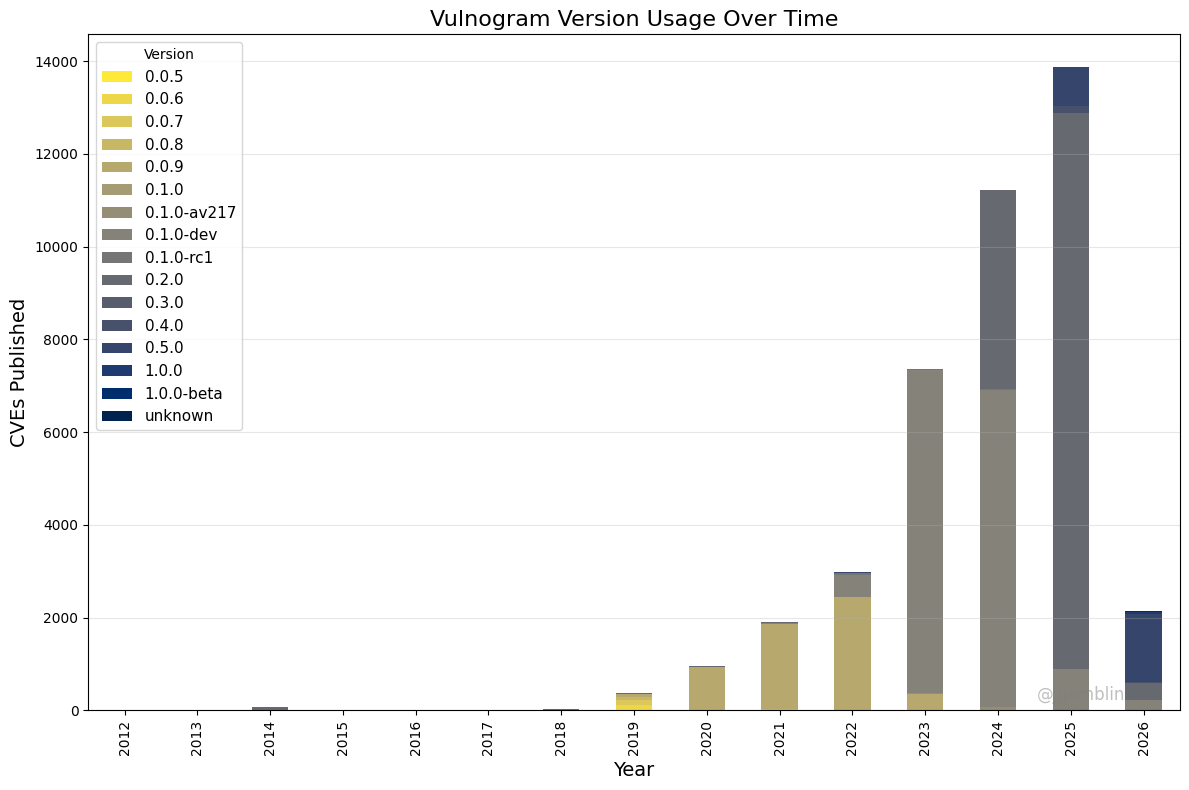

In [13]:
# Group by Year and Version
grouped = vulnogram_df.groupby(['Year', 'Version']).size().reset_index(name='Count')
pivot = grouped.pivot(index='Year', columns='Version', values='Count').fillna(0)

fig, ax = plt.subplots(figsize=(12, 8))
pivot.plot(kind='bar', stacked=True, colormap='cividis_r', ax=ax)

plt.title('Vulnogram Version Usage Over Time', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('CVEs Published', fontsize=14)
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='Version', fontsize=11)

plt.text(0.95, 0.01, '@jgamblin', verticalalignment='bottom', horizontalalignment='right',
         transform=ax.transAxes, color='grey', fontsize=12, alpha=0.5)

plt.tight_layout()
plt.savefig('vulnogram_versions_by_year.png', dpi=300)
plt.show()

## CNAs Using Old Versions of Vulnogram

CNAs whose most recent CVE filing used a Vulnogram version older than the current release.

In [14]:
# Filter to CVEs from the last 3 months
three_months_ago = pd.Timestamp.now() - pd.DateOffset(months=3)
recent_vulnogram_df = vulnogram_df[vulnogram_df['Date'] >= three_months_ago]

# For each CNA, find the most recent CVE and what version they used
latest_per_cna = (
    recent_vulnogram_df.sort_values('Date')
    .groupby('CNA')
    .last()
    .reset_index()[['CNA', 'CVE', 'Date', 'Version', 'Tool']]
)

# Flag those not on the latest version
latest_per_cna['Current'] = latest_per_cna['Version'].apply(
    lambda v: 'Yes' if v.startswith(LATEST_VERSION) else 'No'
)

# Show CNAs on old versions, sorted by most recent date descending
old_version_cnas = (
    latest_per_cna[latest_per_cna['Current'] == 'No']
    .sort_values('Date', ascending=False)
    .reset_index(drop=True)
)

print(f'CVEs in last 3 months (since {three_months_ago.strftime("%Y-%m-%d")}): {len(recent_vulnogram_df):,}')
print(f'CNAs using Vulnogram: {len(latest_per_cna):,}')
print(f'CNAs on current version ({LATEST_VERSION}): {len(latest_per_cna[latest_per_cna["Current"] == "Yes"]):,}')
print(f'CNAs on old versions: {len(old_version_cnas):,}')
print()
old_version_cnas

CVEs in last 3 months (since 2025-12-12): 2,647
CNAs using Vulnogram: 208
CNAs on current version (1.0.0): 20
CNAs on old versions: 188



,CNA,CVE,Date,Version,Tool,Current
0,qnap,CVE-2025-59388,2026-03-12,0.1.0-dev,Vulnogram 0.1.0-dev,No
1,CERT-PL,CVE-2026-0809,2026-03-12,0.2.0,Vulnogram 0.2.0,No
2,ProgressSoftware,CVE-2026-2513,2026-03-12,0.2.0,Vulnogram 0.2.0,No
3,ASUS,CVE-2026-1878,2026-03-12,0.5.0,Vulnogram 0.5.0,No
4,palo_alto,CVE-2026-0230,2026-03-11,0.1.0-dev,Vulnogram 0.1.0-dev,No
...,...,...,...,...,...,...
183,Radiometer,CVE-2025-14096,2025-12-17,0.5.0,Vulnogram 0.5.0,No
184,Milestone,CVE-2025-0836,2025-12-16,0.5.0,Vulnogram 0.5.0,No
185,TXOne,CVE-2025-14252,2025-12-16,0.5.0,Vulnogram 0.5.0,No
186,Document Fdn.,CVE-2025-14714,2025-12-15,0.2.0,Vulnogram 0.2.0,No


## Old Version Breakdown by Version

In [15]:
# Which old versions are CNAs stuck on?
old_version_summary = (
    old_version_cnas.groupby('Version')['CNA']
    .agg(['count', lambda x: ', '.join(sorted(x))])
    .reset_index()
)
old_version_summary.columns = ['Version', 'CNA Count', 'CNAs']
old_version_summary = old_version_summary.sort_values('CNA Count', ascending=False).reset_index(drop=True)
old_version_summary

,Version,CNA Count,CNAs
0,0.5.0,147,"2N, ABB, AHA, AMD, AMZN, ASRG, ASUS, ASUSTOR1,..."
1,0.2.0,26,"CERT-PL, CPANSec, Canon, DIVD, Deltaww, Docker..."
2,0.1.0-dev,13,"3DS, BLSOPS, CERTVDE, Esri, HW, Joomla, Mitsub..."
3,0.3.0,1,lenovo
4,unknown,1,TuranSec


## Export

In [ ]:
# Export old version CNAs to CSV, sorted by version (old to new)
from packaging.version import Version

export_df = old_version_cnas.copy()
export_df['_sort_key'] = export_df['Version'].apply(lambda v: Version(v) if v != 'unknown' else Version('0.0.0'))
export_df = export_df.sort_values('_sort_key').drop(columns='_sort_key').reset_index(drop=True)
export_df.to_csv('vulnogram_old_versions.csv', index=False)
print(f'Exported {len(export_df)} CNAs on old Vulnogram versions to vulnogram_old_versions.csv (sorted old → new)')

Exported 188 CNAs on old Vulnogram versions to vulnogram_old_versions.csv
